In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as npmtd
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.GDC_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']

case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=False, verbose=False)
# print("\nEcho Parameters:")
# print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor


### Get all programs

In [5]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

#--------- chose a disease --------------------
DISEASE_ID = 'ACC'
DISEASE_ID = 'PAAD'

In [7]:
verbose=True
force=False

imax_tumor=250
imax_normal=50

gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

exclude_prog_list=['CCLE']

dfn_tumor, dfn_normal, df_gtex, df_summ = gdc.get_all_data_from_disease(disease_id=DISEASE_ID, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)
print("\n")
print(">> dfn_tumor", dfn_tumor.shape)
print(">> dfn_normal", dfn_normal.shape)

df_summ

Table opened ((89, 12)) at '/home/flavio/uv/perturb_agent/data/gdc_to_cbioportal_study_mapping.tsv'
Table opened ((60616, 460)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_tumor_counts_all_samples.tsv'
Table opened ((60616, 103)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_normal_counts_all_samples.tsv'
Table opened ((74628, 17)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv'
Table opened ((3, 6)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_summary.tsv'


>> dfn_tumor (60616, 460)
>> dfn_normal (60616, 103)


,prog_id,psi_id,disease_id,primary_site,n_tumors,n_normals
0,CPTAC,CPTAC-PAAD,PAAD,Pancreas,213,50
1,CPTAC,CPTAC-PAAD_GDC,PAAD,Pancreas,213,50
2,TCGA,TCGA-PAAD,PAAD,Pancreas,31,1


### Batch effect correction

In [12]:
force=False
verbose=True

perc_min_samples=0.25; top_n=10_000

df_combat = gdc.calc_cpm_merge_turmor_and_normal_batch_correction(dfn_tumor=dfn_tumor, dfn_normal=dfn_normal,
                                                                  perc_min_samples=perc_min_samples, top_n=top_n,
                                                                  force=force, verbose=verbose)
print(df_combat.shape)
df_combat.head(3)

Table opened ((10000, 458)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_sel_log_CPM_top_10000_genes_all_samples.tsv'
Table opened ((20024, 458)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_log_CPM_all_samples.tsv'
Table opened ((10000, 3)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/Tumor_expression_gene_annot_top_10000_genes_all_samples.tsv'
Table opened ((20024, 1163)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/cpm_log_all_genes_all_rows.tsv'
Table opened ((10000, 560)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/combat_log_exp_tumor_and_normal.tsv'
(10000, 560)


,geneid,symbol,biotype,1,2,3,4,5,6,7,...,548,549,550,551,552,553,554,555,556,557
0,ENSG00000270641,TSIX,lncRNA,13.955,13.211,13.898,13.478,13.710,11.679,13.350,...,2.868,3.028,5.113,2.322,3.620,4.659,13.198,4.548,3.652,14.046
1,ENSG00000262619,LINC00621,lncRNA,10.371,10.430,12.476,12.408,14.294,9.301,12.063,...,1.102,1.409,2.019,0.461,0.589,2.182,2.404,4.046,3.690,2.335
2,ENSG00000281383,FP671120.7,lncRNA,3.266,-0.078,10.497,-0.078,11.041,5.579,2.968,...,-0.146,-0.146,-0.146,-0.146,-0.146,-0.146,1.137,-0.146,0.574,-0.146


In [13]:
gdc.dfn.head(3)

,1,2,3,4,5,6,7,8,9,10,...,548,549,550,551,552,553,554,555,556,557
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000270641,14.479,13.720,14.420,13.992,14.229,12.156,13.862,13.964,13.765,13.668,...,3.042,3.204,5.332,2.484,3.808,4.869,13.583,4.755,3.841,14.448
ENSG00000262619,10.816,10.877,12.968,12.899,14.828,9.721,12.547,10.455,9.238,13.277,...,1.383,1.696,2.320,0.728,0.859,2.488,2.714,4.393,4.029,2.643
ENSG00000281383,3.418,0.000,10.809,0.000,11.366,5.782,3.113,0.000,0.000,0.759,...,0.000,0.000,0.000,0.000,0.000,0.000,1.312,0.000,0.737,0.000


### Metadata

In [14]:
print(pd.crosstab(gdc.df_metadata["dataset"], gdc.df_metadata["condition"]))

condition       normal  tumor
dataset                      
CPTAC-PAAD          50    213
CPTAC-PAAD_GDC      50    213
TCGA-PAAD            0     31


### Loop all clusters

In [15]:
disease_id=DISEASE_ID
imax_tumor=250
imax_normal=50
exclude_prog_list=['CCLE']
n_components = 10
n_umap_neighbors=5; min_umap_dist=0.2; umap_metric="euclidean"
method_hca="ward"; hca_criterion="maxclust"
LFC_cutoff=1; FDR_cutoff=0.05

force=True
verbose=False

group = 'Tumor'

n_clusters=5
print(f"Clusters: {n_clusters}")

# for silhouette
min_clusters = 3
max_clusters = n_clusters+2

df_cluster, df_pca, df_umap = gdc.cluster_PCA_HCA_UMAP(df_combat, group=group, n_clusters=n_clusters, 
                                                n_components=n_components, min_clusters=min_clusters, max_clusters=max_clusters,
                                                n_umap_neighbors=n_umap_neighbors, min_umap_dist=min_umap_dist, umap_metric=umap_metric,
                                                method_hca=method_hca, hca_criterion=hca_criterion,
                                                LFC_cutoff=LFC_cutoff, FDR_cutoff=FDR_cutoff,
                                                force=force, verbose=verbose)

df_hca = gdc.df_hca
df_metadata = gdc.df_metadata

lista = df_metadata[df_metadata.condition == 'normal'].index.to_list()
mini = np.min(lista)

normal_clusters = np.unique(df_hca[df_hca['sample'] >= mini].cluster)
normal_clusters


Clusters: 5
Calc PCA ...
Calc best cluster ...
Calc PCA-UMAP ...
Find clusters' signature genes ...
Unique signature genes ...
Cluster 1: 4444 signature genes
Cluster 2: 4362 signature genes
Cluster 3: 2962 signature genes
Cluster 4: 694 signature genes
Cluster 5: 394 signature genes

-------------- end ------------------



array([3, 4], dtype=int32)

In [17]:
gdc.df_umap

,UMAP1,UMAP2,sample,cluster
0,-4.933,-1.888,1,2
1,10.829,9.325,2,1
2,-7.518,-2.086,3,2
3,11.192,8.795,4,1
4,-7.913,15.329,5,2
...,...,...,...,...
552,3.121,15.671,553,1
553,2.820,13.770,554,1
554,5.621,3.933,555,1
555,17.722,3.517,556,1


In [18]:
dfall = gdc.dfall
dfall

,geneid,symbol,biotype,1,2,3,4,5,6,7,...,548,549,550,551,552,553,554,555,556,557
0,ENSG00000000005,TNMD,protein_coding,3.149,3.383,2.111,2.920,2.814,2.531,2.460,...,2.536,2.618,1.082,2.105,2.994,2.446,2.336,2.304,1.903,2.254
1,ENSG00000000419,DPM1,protein_coding,3.418,2.462,3.943,1.673,3.758,1.505,1.701,...,2.536,1.368,1.693,2.105,2.017,1.513,2.193,1.672,0.477,2.254
2,ENSG00000000457,SCYL3,protein_coding,6.607,6.504,7.211,7.223,7.385,7.459,6.810,...,5.976,6.528,6.244,6.075,6.088,6.188,6.431,5.866,5.803,6.529
3,ENSG00000000460,C1orf112,protein_coding,6.951,7.446,6.845,7.394,7.298,6.779,7.637,...,6.759,7.508,7.315,6.810,7.078,7.748,6.882,7.196,6.295,7.398
4,ENSG00000000971,CFH,protein_coding,2.212,0.496,2.708,2.171,4.541,0.452,0.536,...,2.423,0.481,2.451,1.977,0.000,1.988,0.778,2.304,2.408,1.813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20019,ENSG00000288611,NPBWR1,protein_coding,3.938,0.496,3.836,0.524,5.004,1.680,2.460,...,0.905,0.481,1.693,0.000,1.455,1.079,0.562,1.672,0.000,0.505
20020,ENSG00000288612,AL133351.4,lncRNA,0.489,1.609,1.075,2.023,2.236,4.480,2.053,...,3.574,3.020,7.321,2.529,5.265,3.135,1.856,4.721,2.297,5.038
20021,ENSG00000288642,CDR1,protein_coding,6.854,2.566,9.519,3.949,8.535,5.713,4.761,...,7.463,7.407,6.449,6.805,6.270,7.023,4.828,8.240,7.913,6.957
20022,ENSG00000288663,AC073611.1,lncRNA,2.212,1.401,2.708,1.210,2.610,1.072,0.926,...,1.670,1.128,1.517,0.794,2.164,3.307,7.037,2.170,1.360,0.878


### Kennedy pathway

![Kennedy pathway](../figures/WP3933_kennety_pathway.png)

In [20]:
genesk_col = ['CHKA', 'CHKB', 'CHPT1', 'PCYT1A', 'PCYT1B']
genesk_eta = ['SGPL1', 'ETNK1', 'ETNK2', 'PCYT2', 'CEPT1']

genesk_all = genesk_col + genesk_eta
"; ".join(genesk_all)


'CHKA; CHKB; CHPT1; PCYT1A; PCYT1B; SGPL1; ETNK1; ETNK2; PCYT2; CEPT1'

In [21]:
df2 = dfall[dfall.symbol.isin(genesk_all)]
print(df2.shape)
df2

(8, 1263)


,geneid,symbol,biotype,1,2,3,4,5,6,7,...,548,549,550,551,552,553,554,555,556,557
2552,ENSG00000110721,CHKA,protein_coding,5.628,6.256,5.976,6.115,5.609,4.249,5.328,...,5.057,4.919,5.312,5.009,4.851,4.315,4.988,4.721,4.961,5.259
2638,ENSG00000111666,CHPT1,protein_coding,5.159,4.558,3.454,3.286,2.372,2.107,2.573,...,4.717,5.223,4.347,4.218,3.900,3.685,3.551,2.833,2.937,4.400
4494,ENSG00000134255,CEPT1,protein_coding,7.930,7.467,6.886,6.592,6.794,6.443,6.889,...,7.634,7.931,8.212,7.713,7.589,7.059,6.336,6.907,6.879,7.715
5064,ENSG00000139163,ETNK1,protein_coding,2.081,1.952,3.454,2.742,4.183,1.837,3.186,...,2.916,1.128,1.850,1.071,0.904,1.689,1.948,1.209,0.477,1.175
5527,ENSG00000143845,ETNK2,protein_coding,3.548,3.820,2.933,2.645,4.255,3.939,3.322,...,4.427,4.738,1.992,3.902,4.956,3.880,3.223,3.077,2.408,4.312
6806,ENSG00000161217,PCYT1A,protein_coding,4.920,5.213,3.836,3.286,6.013,0.795,6.405,...,2.423,1.573,2.719,1.071,1.455,2.235,1.758,3.000,3.483,2.376
7492,ENSG00000166224,SGPL1,protein_coding,3.275,2.098,4.308,2.540,5.162,1.978,3.322,...,3.146,3.020,3.140,2.434,3.071,2.714,2.642,2.022,1.903,2.689
9594,ENSG00000185813,PCYT2,protein_coding,2.212,3.136,1.684,2.171,2.087,3.631,2.337,...,2.301,3.020,2.546,1.977,2.638,1.312,2.847,1.459,2.511,3.022


In [50]:
df_hca = gdc.df_hca
df_metadata = gdc.df_metadata

lista = df_metadata[df_metadata.condition == 'normal'].index.to_list()
mini = np.min(lista)

normal_clusters = np.unique(df_hca[df_hca['sample'] >= mini].cluster)
normal_clusters

array([3, 4], dtype=int32)

In [51]:
df_hca.cluster.unique()

array([1, 5, 4, 2, 3], dtype=int32)

In [52]:
nclu = 1

cols = gdc.df_hca[gdc.df_hca.cluster == nclu]['sample'].to_list()
cols = [str(x) for x in cols]

df2 = dfall[dfall.symbol.isin(genesk_all)]

df2 = df2[gdc.ANNOT_COLS + cols]
print(df2.shape)
df2


(8, 79)


,geneid,symbol,biotype,1,3,5,14,16,17,20,...,292,295,299,303,306,308,309,312,325,373
2552,ENSG00000110721,CHKA,protein_coding,5.628,5.976,5.609,4.576,4.600,4.675,5.263,...,5.635,5.503,5.282,4.356,5.376,6.332,5.580,5.725,5.883,5.758
2638,ENSG00000111666,CHPT1,protein_coding,5.159,3.454,2.372,5.119,4.185,3.944,3.639,...,2.857,3.422,3.090,3.829,4.093,3.916,4.043,3.900,3.215,4.066
4494,ENSG00000134255,CEPT1,protein_coding,7.930,6.886,6.794,7.871,8.035,7.715,7.222,...,8.236,7.503,6.876,6.756,6.845,7.810,7.453,7.628,7.050,8.130
5064,ENSG00000139163,ETNK1,protein_coding,2.081,3.454,4.183,3.297,3.922,3.243,4.814,...,4.224,1.638,4.229,2.163,3.452,4.169,3.863,2.441,3.790,3.359
5527,ENSG00000143845,ETNK2,protein_coding,3.548,2.933,4.255,1.355,2.335,0.885,2.384,...,2.680,1.984,3.201,2.553,3.727,2.475,3.417,3.156,2.890,3.018
6806,ENSG00000161217,PCYT1A,protein_coding,4.920,3.836,6.013,5.697,3.184,5.451,3.639,...,6.047,6.835,4.924,6.906,1.720,4.804,5.521,2.993,4.045,3.124
7492,ENSG00000166224,SGPL1,protein_coding,3.275,4.308,5.162,4.478,3.262,3.306,5.016,...,4.208,3.773,4.536,5.216,4.982,4.297,4.375,2.600,4.552,4.459
9594,ENSG00000185813,PCYT2,protein_coding,2.212,1.684,2.087,3.219,2.335,2.266,3.144,...,2.114,2.497,2.250,0.000,3.884,2.932,1.891,1.820,2.666,2.031


In [53]:
df3 = df2.set_index('symbol')[cols]
df3.mean(axis=1)

symbol
CHKA      5.400
CHPT1     3.652
CEPT1     7.508
ETNK1     3.227
ETNK2     2.841
PCYT1A    4.778
SGPL1     4.101
PCYT2     2.326
dtype: float64

In [54]:
dic = {'nclu': nclu, 'symbol': df3.index, 'mu': np.array(df3.mean(axis=1)), 'std': np.array(df3.std(axis=1)), 'n': len(cols)}
df = pd.DataFrame(dic)
df

,nclu,symbol,mu,std,n
0,1,CHKA,5.400,0.531,76
1,1,CHPT1,3.652,0.765,76
2,1,CEPT1,7.508,0.583,76
3,1,ETNK1,3.227,0.781,76
4,1,ETNK2,2.841,0.999,76
5,1,PCYT1A,4.778,1.375,76
6,1,SGPL1,4.101,0.639,76
7,1,PCYT2,2.326,0.849,76


In [83]:
df_list = []

for nclu, group, order in [(1,'SEV1', 4), (2,'SEV2', 3), (3,'CTRL', 1), (5,'MILD', 2)]:

    if nclu == 3:
        cols = gdc.df_hca[gdc.df_hca.cluster == 3]['sample'].to_list() + gdc.df_hca[gdc.df_hca.cluster == 4]['sample'].to_list()
    else:
        cols = gdc.df_hca[gdc.df_hca.cluster == nclu]['sample'].to_list()

    cols = [str(x) for x in cols]
    print(f"Cluster {nclu} ({group}): {len(cols)} - {';'.join(cols)}")

    df2 = dfall[dfall.symbol.isin(genesk_all)]
    df2 = df2[gdc.ANNOT_COLS + cols]

    df3 = df2.set_index('symbol')[cols]

    dic = {'nclu': nclu, 'group': group, 'order': order, 'symbol': df3.index, 'mu': np.array(df3.mean(axis=1)), 'std': np.array(df3.std(axis=1)), 'n': len(cols)}
    dfa = pd.DataFrame(dic)

    df_list.append(dfa)

df = pd.concat(df_list, ignore_index=True)
df = df.sort_values(['symbol', 'order'])


symbols = df.symbol.unique()
'''
lista = []
for symb in symbols:
    dfa = df[df.symbol == symb]
    mu_ref = dfa[dfa.group == 'CTRL'].mu.values[0]
    vals = list(dfa['mu'] - mu_ref)
    lista += vals

df['mu_ref'] = lista
'''
ctrl_mu = (
    df[df["group"] == "CTRL"]
    .set_index("symbol")["mu"]
    .to_dict()
)

ctrl_std = (
    df[df["group"] == "CTRL"]
    .set_index("symbol")["std"]
    .to_dict()
)

df["std"] = df.apply(
    lambda r:  ctrl_std[r["symbol"]],
    axis=1
)

df["mu_ref"] = df.apply(
    lambda r: r["mu"] - ctrl_mu[r["symbol"]],
    axis=1
)

df["std_ref"] = df.apply(
    lambda r: np.sqrt(r["std"]**2 + ctrl_std[r["symbol"]]**2),
    axis=1
)

df['sem_ref'] = df['std_ref'] / np.sqrt(df['n'])
df['ci_inf_ref'] = df['mu_ref'] - 1.96 * df['sem_ref']
df['ci_sup_ref'] = df['mu_ref'] + 1.96 * df['sem_ref']


cols = ['nclu', 'group', 'order', 'symbol',  'mu_ref', 'ci_inf_ref', 'ci_sup_ref', 'sem_ref', 'mu', 'std', 'n']
df = df[cols]
df


Cluster 1 (SEV1): 76 - 1;3;5;14;16;17;20;22;23;25;28;30;32;33;38;39;42;43;45;52;55;56;63;65;70;73;75;77;79;82;86;90;93;95;96;99;112;160;214;216;218;219;228;230;231;234;236;237;239;242;244;246;247;252;253;256;257;259;266;269;276;278;283;286;288;290;292;295;299;303;306;308;309;312;325;373
Cluster 2 (SEV2): 44 - 11;36;48;51;59;61;67;85;89;101;102;104;111;120;127;131;142;144;146;151;155;163;225;250;262;265;272;274;280;298;302;314;315;317;324;333;340;344;355;357;359;364;368;376
Cluster 3 (CTRL): 288 - 458;459;460;461;462;463;464;465;466;467;468;469;473;474;475;476;478;479;480;481;482;484;485;486;487;488;489;491;492;493;494;495;496;498;499;500;503;504;505;506;508;509;510;511;512;514;515;516;517;518;519;520;521;523;525;526;527;528;529;531;532;533;535;536;537;538;540;541;542;543;544;545;546;548;549;550;551;552;556;557;10;103;105;106;107;108;109;110;113;114;115;116;117;118;119;121;122;123;124;125;126;128;129;130;132;133;134;135;136;137;138;139;140;141;143;145;147;148;149;150;152;153;154;156;157

,nclu,group,order,symbol,mu_ref,ci_inf_ref,ci_sup_ref,sem_ref,mu,std,n
18,3,CTRL,1,CEPT1,0.000,-0.093,0.093,0.047,7.306,0.568,288
26,5,MILD,2,CEPT1,-0.527,-0.656,-0.398,0.066,6.779,0.568,149
10,2,SEV2,3,CEPT1,-0.972,-1.209,-0.734,0.121,6.334,0.568,44
2,1,SEV1,4,CEPT1,0.202,0.021,0.382,0.092,7.508,0.568,76
16,3,CTRL,1,CHKA,0.000,-0.103,0.103,0.052,5.112,0.628,288
24,5,MILD,2,CHKA,0.258,0.116,0.401,0.073,5.371,0.628,149
8,2,SEV2,3,CHKA,-0.891,-1.154,-0.629,0.134,4.221,0.628,44
0,1,SEV1,4,CHKA,0.287,0.088,0.487,0.102,5.400,0.628,76
17,3,CTRL,1,CHPT1,0.000,-0.119,0.119,0.061,3.245,0.730,288
25,5,MILD,2,CHPT1,0.439,0.273,0.604,0.085,3.684,0.730,149


In [85]:
fname = 'kennedy_genes.tsv'
pdwritecsv(df, fname, gdc.root_mprog_lfc)

True

In [86]:
gene = 'CHKA'

df[df.symbol == gene]

,nclu,group,order,symbol,mu_ref,ci_inf_ref,ci_sup_ref,sem_ref,mu,std,n
16,3,CTRL,1,CHKA,0.000,-0.103,0.103,0.052,5.112,0.628,288
24,5,MILD,2,CHKA,0.258,0.116,0.401,0.073,5.371,0.628,149
8,2,SEV2,3,CHKA,-0.891,-1.154,-0.629,0.134,4.221,0.628,44
0,1,SEV1,4,CHKA,0.287,0.088,0.487,0.102,5.400,0.628,76


### Gene evolution - Kennedy pathway

Genes present: ['CHKA', 'CHPT1', 'PCYT1A', 'SGPL1', 'ETNK1', 'ETNK2', 'PCYT2', 'CEPT1']
Genes missing: ['CHKB', 'PCYT1B']


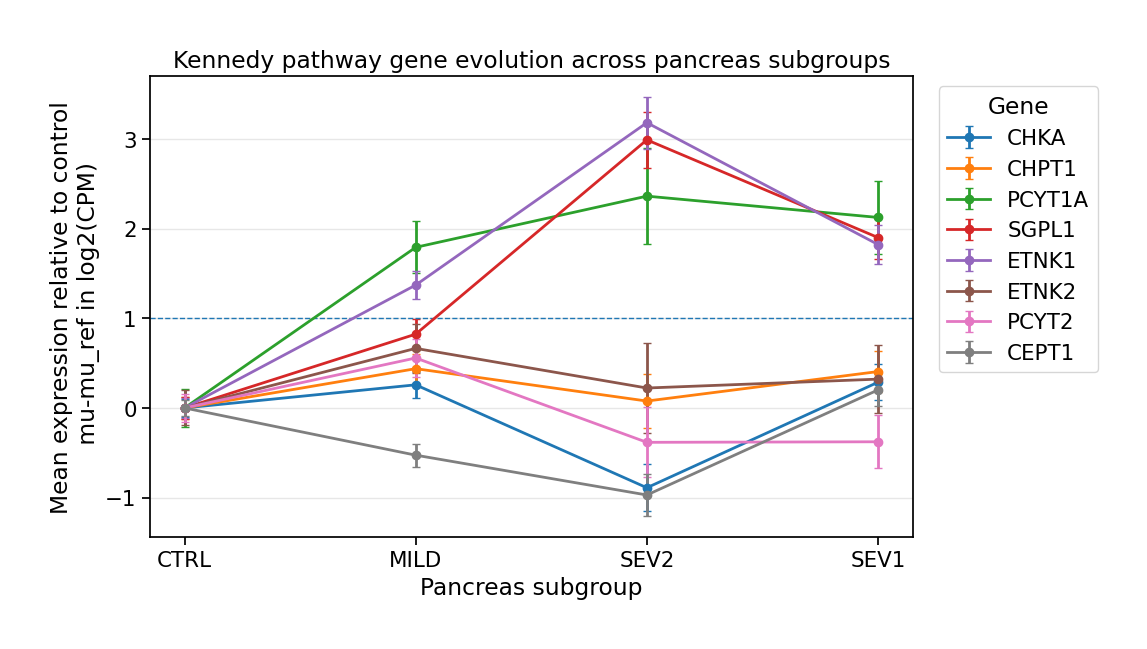

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Kennedy pathway genes
# ============================================================

genesk_col = ["CHKA", "CHKB", "CHPT1", "PCYT1A", "PCYT1B"]
genesk_eta = ["SGPL1", "ETNK1", "ETNK2", "PCYT2", "CEPT1"]

kennedy_genes = genesk_col + genesk_eta


# ============================================================
# Keep only genes present in the uploaded table
# ============================================================

genes_present = [g for g in kennedy_genes if g in df["symbol"].unique()]
genes_missing = [g for g in kennedy_genes if g not in df["symbol"].unique()]

print("Genes present:", genes_present)
print("Genes missing:", genes_missing)


# ============================================================
# Define biological group order
# ============================================================

group_order = ["CTRL", "MILD", "SEV2", "SEV1"]

dff = df[df["symbol"].isin(genes_present)].copy()
dff["group"] = pd.Categorical(
    dff["group"],
    categories=group_order,
    ordered=True
)

dff = dff.sort_values(["symbol", "group"])


# ============================================================
# Plot 1:
# each gene evolution across groups
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

x_positions = np.arange(len(group_order))

for gene in genes_present:
    dfa = dff[dff["symbol"] == gene].sort_values("group")

    y = dfa["mu_ref"].to_numpy()

    yerr_lower = y - dfa["ci_inf_ref"].to_numpy()
    yerr_upper = dfa["ci_sup_ref"].to_numpy() - y
    yerr = np.vstack([yerr_lower, yerr_upper])

    ax.errorbar(
        x_positions,
        y,
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=3,
        label=gene,
    )

ax.axhline(1.0, linestyle="--", linewidth=1)

ax.set_xticks(x_positions)
ax.set_xticklabels(group_order)

ax.set_xlabel("Pancreas subgroup")
ax.set_ylabel("Mean expression relative to control\n mu-mu_ref in log2(CPM)")
ax.set_title("Kennedy pathway gene evolution across pancreas subgroups")

ax.legend(
    title="Gene",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig("kennedy_gene_evolution_mu_ref.png", dpi=300, bbox_inches="tight")
plt.show()




In [95]:
dff

,nclu,group,order,symbol,mu_ref,ci_inf_ref,ci_sup_ref,sem_ref,mu,std,n,mu_ref_for_corr
18,3,CTRL,1,CEPT1,0.000,-0.093,0.093,0.047,7.306,0.568,288,NaN
26,5,MILD,2,CEPT1,-0.527,-0.656,-0.398,0.066,6.779,0.568,149,-0.527
10,2,SEV2,3,CEPT1,-0.972,-1.209,-0.734,0.121,6.334,0.568,44,-0.972
2,1,SEV1,4,CEPT1,0.202,0.021,0.382,0.092,7.508,0.568,76,0.202
16,3,CTRL,1,CHKA,0.000,-0.103,0.103,0.052,5.112,0.628,288,NaN
24,5,MILD,2,CHKA,0.258,0.116,0.401,0.073,5.371,0.628,149,0.258
8,2,SEV2,3,CHKA,-0.891,-1.154,-0.629,0.134,4.221,0.628,44,-0.891
0,1,SEV1,4,CHKA,0.287,0.088,0.487,0.102,5.400,0.628,76,0.287
17,3,CTRL,1,CHPT1,0.000,-0.119,0.119,0.061,3.245,0.730,288,NaN
25,5,MILD,2,CHPT1,0.439,0.273,0.604,0.085,3.684,0.730,149,0.439


### Correlation

In [96]:

# ============================================================
# Plot 2:
# gene-gene correlation heatmap
# Pearson correlation across groups using mu_ref
# ============================================================

# ============================================================
# Blank non-significant mu_ref values before correlation
# CI crosses zero => mu_ref is not clearly different from CTRL
# ============================================================

dff["mu_ref_for_corr"] = dff["mu_ref"].copy()

dff.loc[
    (dff["ci_inf_ref"] <= 0) & (dff["ci_sup_ref"] >= 0),
    "mu_ref_for_corr"
] = np.nan

pivot = (
    dff.pivot_table(
        index="group",
        columns="symbol",
        values="mu_ref_for_corr",
        observed=False,
    )
    .loc[group_order, genes_present]
)

corr = pivot.corr(method="pearson", min_periods=2)



fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="bwr")

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        value = corr.iloc[i, j]

        if np.isnan(value):
            label = ""
        else:
            label = f"{value:.2f}"

        ax.text(
            j,
            i,
            label,
            ha="center",
            va="center",
            fontsize=8,
        )


ax.set_title("Gene-gene correlation across pancreas subgroups")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation of mu_ref")

fig.tight_layout()
fig.savefig("kennedy_gene_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Optional: save correlation table
# ============================================================

corr.to_csv("kennedy_gene_correlation_matrix.tsv", sep="\t")

KeyError: "['CTRL'] not in index"